# Red Neuronal

Implementaremos un Perceptrón Multicapa (MLP), un tipo de red neuronal artificial de propagación hacia adelante. Este modelo es un aproximador universal de funciones, lo que significa que, teóricamente, puede modelar cualquier relación matemática continua entre las entradas y las salidas, por compleja que esta sea.

Tras demostrar empíricamente que los modelos basados en márgenes geométricos (SVM) son incapaces de separar las clases, la hipótesis principal es que la predicción del churn depende de interacciones no lineales latentes y de alto orden entre las variables. Una red neuronal es el candidato ideal para descubrir estas interacciones.

In [ ]:
pip install umap-learn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    auc)

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.decomposition import PCA
import umap
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import trustworthiness

In [2]:
df = pd.read_csv("spotify_churn_dataset.csv")

## Preprocesamiento de los datos

In [3]:
print("Eliminando user_id ya que es un identificador sin varianza predictiva.")
df = df.drop(columns=['user_id'])
print("Eliminando offline_listening por su alta correlación negativa con ads_per_week")
df = df.drop(columns=['offline_listening'])

Eliminando user_id ya que es un identificador sin varianza predictiva.
Eliminando offline_listening por su alta correlación negativa con ads_per_week


In [4]:
# Separar características (X) y variable objetivo (y)
X = df.drop('is_churned', axis=1)
y = df['is_churned']

Usamos *stratify=y* en el split para asegurarnos que en el `train_test_split`, tanto el conjunto de entrenamiento como el de prueba mantengan la proporción original del *74/26*.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")

Dimensiones de X_train: (6400, 9)
Dimensiones de X_test: (1600, 9)


In [6]:
num_cols = ['age', 'listening_time', 'songs_played_per_day', 'skip_rate', 'ads_listened_per_week']
cat_cols = ['gender', 'country', 'subscription_type', 'device_type']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
    ])

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print(f"Dimensiones después de codificar: {X_train_transformed.shape}")

Dimensiones después de codificar: (6400, 19)


## Implementación de la Red Neuronal con MLP Classifier

Una red neuronal tiene muchos parámetros que ajustar (número de capas, neuronas, regularización). Usaremos `GridSearchCV` para probar diferentes arquitecturas y dejar que los datos decidan cuál es la mejor.

In [9]:
# 1. Definir el pipeline
pipeline_nn = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('nn', MLPClassifier(random_state=42, max_iter=1000, early_stopping=True))
])

# 2. Malla de hiperparámetros
param_grid_nn = {
    'nn__hidden_layer_sizes': [(100,), (50, 25)],
    'nn__activation': ['relu', 'tanh'],
    'nn__alpha': [0.0001, 0.001],
    'nn__learning_rate_init': [0.001]
}

# 3. Configurar GridSearchCV
grid_nn = GridSearchCV(
    estimator=pipeline_nn,
    param_grid=param_grid_nn,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=2
)

# 4. Entrenar con los datos
grid_nn.fit(X_train_transformed, y_train)

print("\n--- MEJORES HIPERPARÁMETROS (Red Neuronal) ---")
print(grid_nn.best_params_)

# 5. Evaluación en el conjunto de Test
best_nn = grid_nn.best_estimator_
y_pred_nn = best_nn.predict(X_test_transformed)
y_pred_proba_nn = best_nn.predict_proba(X_test_transformed)[:, 1]

print("\n--- REPORTE DE CLASIFICACIÓN (Red Neuronal) ---")
print(classification_report(y_test, y_pred_nn))

print(f"AUC-ROC Score (Red Neuronal): {roc_auc_score(y_test, y_pred_proba_nn):.4f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits

--- MEJORES HIPERPARÁMETROS (Red Neuronal) ---
{'nn__activation': 'tanh', 'nn__alpha': 0.001, 'nn__hidden_layer_sizes': (100,), 'nn__learning_rate_init': 0.001}

--- REPORTE DE CLASIFICACIÓN (Red Neuronal) ---
              precision    recall  f1-score   support

           0       0.76      0.45      0.57      1186
           1       0.27      0.58      0.37       414

    accuracy                           0.49      1600
   macro avg       0.51      0.52      0.47      1600
weighted avg       0.63      0.49      0.52      1600

AUC-ROC Score (Red Neuronal): 0.5285


Matriz de Confusión

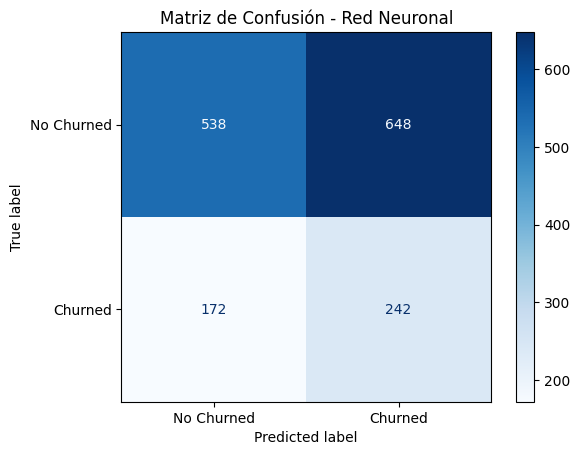

In [40]:
cm_nn = confusion_matrix(y_test, y_pred_nn)
disp_nn = ConfusionMatrixDisplay(confusion_matrix=cm_nn, display_labels=['No Churned', 'Churned'])
disp_nn.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión - Red Neuronal')
plt.show()

Curva AUC-ROC

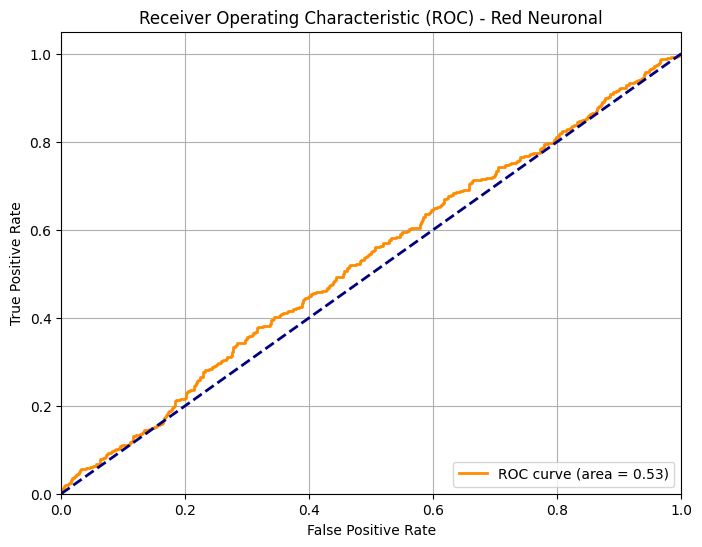

In [41]:
fpr_nn, tpr_nn, thresholds_nn = roc_curve(y_test, y_pred_proba_nn)
roc_auc_nn = auc(fpr_nn, tpr_nn)

plt.figure(figsize=(8, 6))
plt.plot(fpr_nn, tpr_nn, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_nn:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Red Neuronal')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## Redimensión de características

### Red Neuronal con PCA

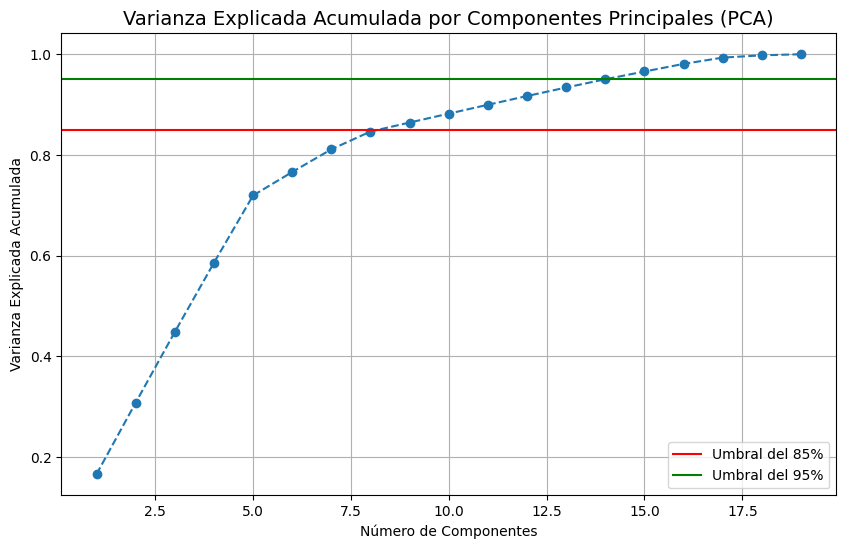

In [7]:
pca_test = PCA()
pca_test.fit(X_train_transformed)

varianza_acumulada = np.cumsum(pca_test.explained_variance_ratio_)

# Gráfico para justificar la elección de componentes
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', linestyle='--')
plt.axhline(y=0.85, color='r', linestyle='-', label='Umbral del 85%') # Nuestra línea de decisión
plt.axhline(y=0.95, color='g', linestyle='-', label='Umbral del 95%')

plt.title('Varianza Explicada Acumulada por Componentes Principales (PCA)', fontsize=14)
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.legend()
plt.grid(True)
plt.show()

Se seleccionó el umbral del 85% de varianza explicada acumulada, correspondiente a 8 componentes principales. Este criterio se apoya en el análisis del scree plot, donde la curva presenta un aplanamiento notable a partir del octavo componente, indicando que los componentes adicionales aportan información marginal. Esto representa una reducción del 58% en la dimensionalidad original.

In [12]:
pca = PCA(n_components=0.85)
X_train_pca = pca.fit_transform(X_train_transformed)
X_test_pca  = pca.transform(X_test_transformed)
reduccion = (1 - X_train_pca.shape[1] / X_train_transformed.shape[1]) * 100

print(f"Features originales: {X_train_transformed.shape[1]} → componentes PCA: {X_train_pca.shape[1]}")
print(f"Varianza explicada: {pca.explained_variance_ratio_.sum():.2%}")
print(f"Porcentaje de reducción: {reduccion:.1f}%")

pipeline_nn_pca = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('nn', MLPClassifier(random_state=42, max_iter=1000, early_stopping=True))
])

grid_nn_pca = GridSearchCV(
    estimator=pipeline_nn_pca,
    param_grid=param_grid_nn,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_nn_pca.fit(X_train_pca, y_train)

best_nn_pca = grid_nn_pca.best_estimator_
y_pred_nn_pca = best_nn_pca.predict(X_test_pca)
y_pred_proba_nn_pca = best_nn_pca.predict_proba(X_test_pca)[:, 1]

print("\n--- MEJORES HIPERPARÁMETROS (Red Neuronal + PCA) ---")
print(grid_nn_pca.best_params_)
print("\n--- REPORTE DE CLASIFICACIÓN (Red Neuronal + PCA) ---")
print(classification_report(y_test, y_pred_nn_pca))
print(f"AUC-ROC Score (Red Neuronal + PCA): {roc_auc_score(y_test, y_pred_proba_nn_pca):.4f}")

Features originales: 19 → componentes PCA: 9
Varianza explicada: 86.43%
Porcentaje de reducción: 52.6%
Fitting 5 folds for each of 8 candidates, totalling 40 fits

--- MEJORES HIPERPARÁMETROS (Red Neuronal + PCA) ---
{'nn__activation': 'tanh', 'nn__alpha': 0.0001, 'nn__hidden_layer_sizes': (100,), 'nn__learning_rate_init': 0.001}

--- REPORTE DE CLASIFICACIÓN (Red Neuronal + PCA) ---
              precision    recall  f1-score   support

           0       0.73      0.42      0.53      1186
           1       0.25      0.56      0.35       414

    accuracy                           0.45      1600
   macro avg       0.49      0.49      0.44      1600
weighted avg       0.61      0.45      0.48      1600

AUC-ROC Score (Red Neuronal + PCA): 0.4968


Matriz de confusión

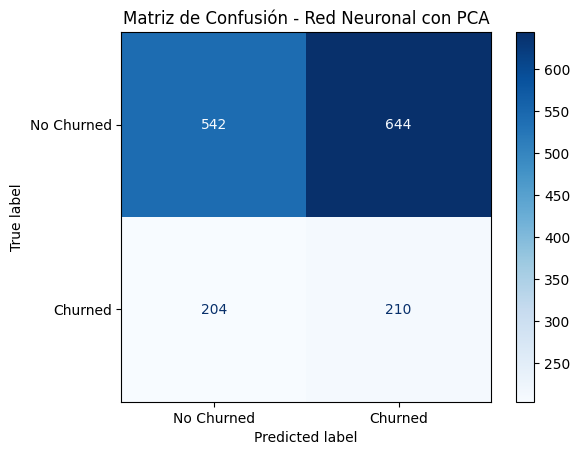

In [45]:
cm_nn_pca = confusion_matrix(y_test, y_pred_nn_pca)
disp_nn_pca = ConfusionMatrixDisplay(confusion_matrix=cm_nn_pca, display_labels=['No Churned', 'Churned'])
disp_nn_pca.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión - Red Neuronal con PCA')
plt.show()

Curva AUC-ROC

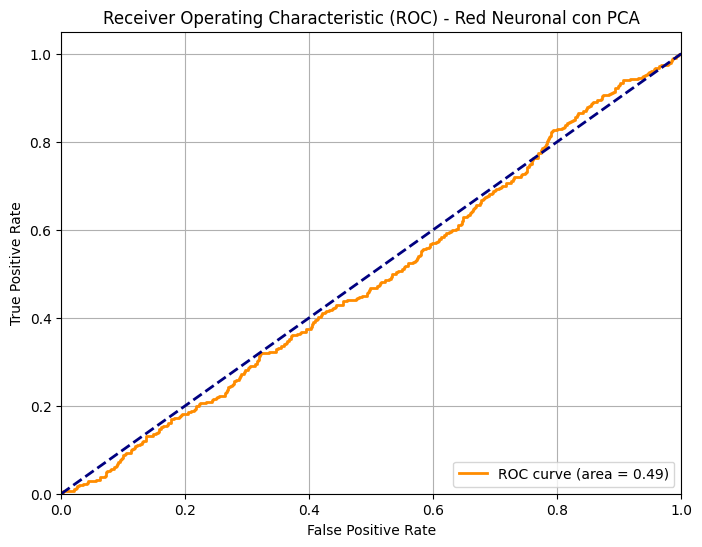

In [59]:
fpr_nn_pca, tpr_nn_pca, thresholds_nn_pca = roc_curve(y_test, y_pred_proba_nn_pca)
roc_auc_nn_pca = auc(fpr_nn_pca, tpr_nn_pca)

plt.figure(figsize=(8, 6))
plt.plot(fpr_nn_pca, tpr_nn_pca, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_nn_pca:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Red Neuronal con PCA')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Red Neuronal con UMAP

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


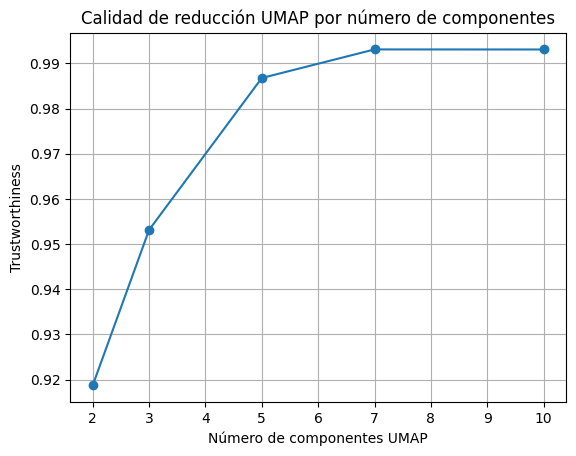

In [48]:
scores = []
componentes = [2, 3, 5, 7, 10]

for n in componentes:
    reducer = umap.UMAP(n_components=n, random_state=42)
    X_embedded = reducer.fit_transform(X_train_transformed)
    score = trustworthiness(X_train_transformed, X_embedded, n_neighbors=10)
    scores.append(score)

plt.plot(componentes, scores, marker='o')
plt.xlabel('Número de componentes UMAP')
plt.ylabel('Trustworthiness')
plt.title('Calidad de reducción UMAP por número de componentes')
plt.grid(True)
plt.show()

Se evaluó la calidad de la reducción mediante la métrica trustworthiness, que mide qué tan bien UMAP preserva las relaciones de vecindad local de los datos originales. Se seleccionaron 5 componentes, punto a partir del cual la curva se aplana con un trustworthiness de 0.987, indicando que componentes adicionales aportan mejoras marginales. Esto representa una reducción del 74% respecto a las 19 features originales.

In [49]:
reducer = umap.UMAP(n_components=5, random_state=42)
X_train_umap = reducer.fit_transform(X_train_transformed)
X_test_umap  = reducer.transform(X_test_transformed)

print(f"Features originales: {X_train.shape[1]} → componentes UMAP: {X_train_umap.shape[1]}")

pipeline_nn_umap = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('nn', MLPClassifier(random_state=42, max_iter=1000, early_stopping=True))
])

grid_nn_umap = GridSearchCV(
    estimator=pipeline_nn_umap,
    param_grid=param_grid_nn,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_nn_umap.fit(X_train_umap, y_train)

best_nn_umap = grid_nn_umap.best_estimator_
y_pred_nn_umap = best_nn_umap.predict(X_test_umap)
y_pred_proba_nn_umap = best_nn_umap.predict_proba(X_test_umap)[:, 1]

print("\n--- MEJORES HIPERPARÁMETROS (Red Neuronal + UMAP) ---")
print(grid_nn_umap.best_params_)
print("\n--- REPORTE DE CLASIFICACIÓN (Red Neuronal + UMAP) ---")
print(classification_report(y_test, y_pred_nn_umap))
print(f"AUC-ROC Score (Red Neuronal + UMAP): {roc_auc_score(y_test, y_pred_proba_nn_umap):.4f}")

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Features originales: 9 → componentes UMAP: 5
Fitting 5 folds for each of 8 candidates, totalling 40 fits

--- MEJORES HIPERPARÁMETROS (Red Neuronal + UMAP) ---
{'nn__activation': 'relu', 'nn__alpha': 0.001, 'nn__hidden_layer_sizes': (50, 25), 'nn__learning_rate_init': 0.001}

--- REPORTE DE CLASIFICACIÓN (Red Neuronal + UMAP) ---
              precision    recall  f1-score   support

           0       0.74      0.76      0.75      1186
           1       0.24      0.22      0.23       414

    accuracy                           0.62      1600
   macro avg       0.49      0.49      0.49      1600
weighted avg       0.61      0.62      0.62      1600

AUC-ROC Score (Red Neuronal + UMAP): 0.4761


Matriz de confusión

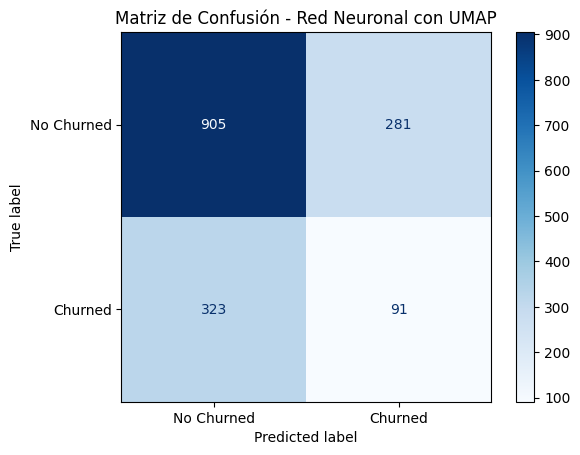

In [57]:
cm_nn_umap = confusion_matrix(y_test, y_pred_nn_umap)
disp_nn_umap = ConfusionMatrixDisplay(confusion_matrix=cm_nn_umap, display_labels=['No Churned', 'Churned'])
disp_nn_umap.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión - Red Neuronal con UMAP')
plt.show()

Curva ROC-AUC

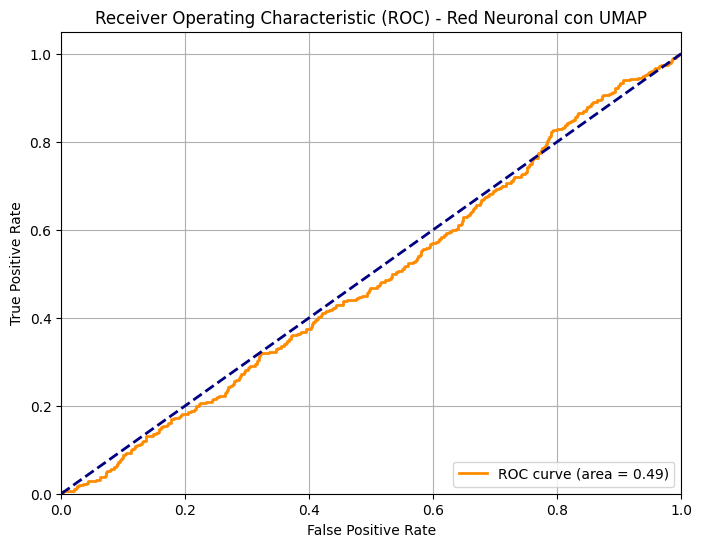

In [58]:
fpr_nn_umap, tpr_nn_umap, thresholds_nn_umap = roc_curve(y_test, y_pred_proba_nn_umap)
roc_auc_nn_umap = auc(fpr_nn_umap, tpr_nn_umap)

plt.figure(figsize=(8, 6))
plt.plot(fpr_nn_pca, tpr_nn_pca, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_nn_pca:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Red Neuronal con UMAP')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Red Neuronal con LDA

Features originales: 19 → componentes LDA: 1


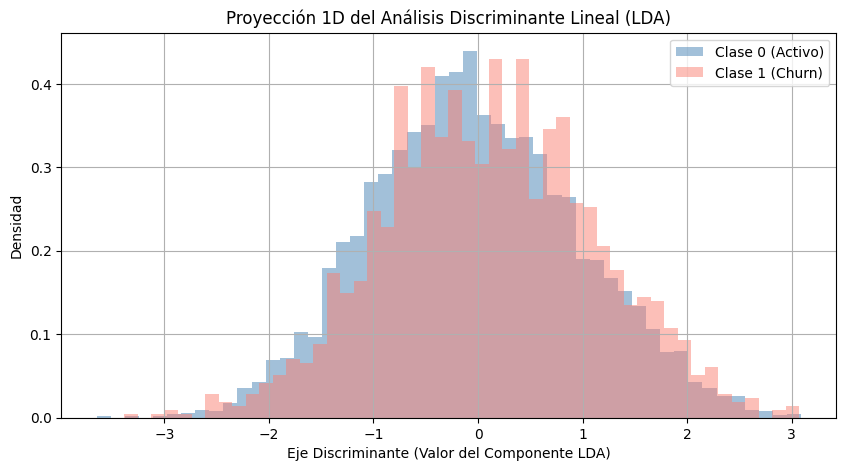

Fitting 5 folds for each of 8 candidates, totalling 40 fits

--- MEJORES HIPERPARÁMETROS (Red Neuronal + LDA) ---
{'nn__activation': 'relu', 'nn__alpha': 0.0001, 'nn__hidden_layer_sizes': (50, 25), 'nn__learning_rate_init': 0.001}

--- REPORTE DE CLASIFICACIÓN (Red Neuronal + LDA) ---
              precision    recall  f1-score   support

           0       0.75      0.56      0.64      1186
           1       0.26      0.45      0.33       414

    accuracy                           0.53      1600
   macro avg       0.51      0.51      0.49      1600
weighted avg       0.62      0.53      0.56      1600

AUC-ROC Score (Red Neuronal + LDA): 0.4955


In [53]:
# LDA como reductor (supervisado, usa y_train)
lda = LinearDiscriminantAnalysis()
X_train_lda = lda.fit_transform(X_train_transformed, y_train)  # necesita y_train
X_test_lda  = lda.transform(X_test_transformed)

print(f"Features originales: {X_train_transformed.shape[1]} → componentes LDA: {X_train_lda.shape[1]}")

# Gráfico de proyección 1D
plt.figure(figsize=(10, 5))
for clase, color, label in [(0, 'steelblue', 'Clase 0 (Activo)'), (1, 'salmon', 'Clase 1 (Churn)')]:
    mask = y_train == clase
    plt.hist(X_train_lda[mask, 0], bins=50, alpha=0.5, color=color, label=label, density=True)

plt.xlabel('Eje Discriminante (Valor del Componente LDA)')
plt.ylabel('Densidad')
plt.title('Proyección 1D del Análisis Discriminante Lineal (LDA)')
plt.legend()
plt.grid(True)
plt.show()

# Pipeline y GridSearch
pipeline_nn_lda = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('nn', MLPClassifier(random_state=42, max_iter=1000, early_stopping=True))
])

grid_nn_lda = GridSearchCV(
    estimator=pipeline_nn_lda,
    param_grid=param_grid_nn,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_nn_lda.fit(X_train_lda, y_train)

best_nn_lda = grid_nn_lda.best_estimator_
y_pred_nn_lda = best_nn_lda.predict(X_test_lda)
y_pred_proba_nn_lda = best_nn_lda.predict_proba(X_test_lda)[:, 1]

print("\n--- MEJORES HIPERPARÁMETROS (Red Neuronal + LDA) ---")
print(grid_nn_lda.best_params_)
print("\n--- REPORTE DE CLASIFICACIÓN (Red Neuronal + LDA) ---")
print(classification_report(y_test, y_pred_nn_lda))
print(f"AUC-ROC Score (Red Neuronal + LDA): {roc_auc_score(y_test, y_pred_proba_nn_lda):.4f}")

Matriz de Confusión

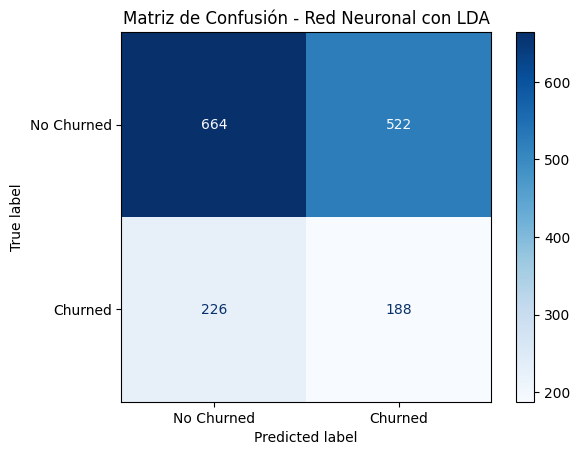

In [60]:
cm_nn_lda = confusion_matrix(y_test, y_pred_nn_lda)
disp_nn_lda = ConfusionMatrixDisplay(confusion_matrix=cm_nn_lda, display_labels=['No Churned', 'Churned'])
disp_nn_lda.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión - Red Neuronal con LDA')
plt.show()

Curva ROC-AUC

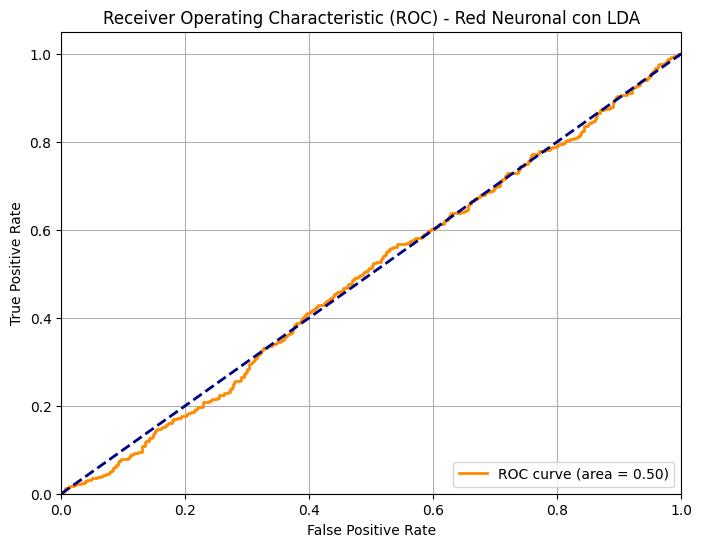

In [61]:
fpr_nn_lda, tpr_nn_lda, thresholds_nn_lda = roc_curve(y_test, y_pred_proba_nn_lda)
roc_auc_nn_lda = auc(fpr_nn_lda, tpr_nn_lda)

plt.figure(figsize=(8, 6))
plt.plot(fpr_nn_lda, tpr_nn_lda, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_nn_lda:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Red Neuronal con LDA')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()